In [1]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install scikit-learn
!pip install seaborn
!pip install xgboost

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from xgboost import XGBClassifier

In [3]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.count()

,0
survived,891
pclass,891
sex,891
age,714
sibsp,891
parch,891
fare,891
embarked,889
class,891
who,891


In [5]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']
target = 'survived'

X = titanic[features]
y = titanic[target]

In [6]:
#how balanced are the classes?
y.value_counts()

,count
survived,
0,549
1,342


In [7]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
#automatically detect numerical and categorical features
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [9]:
#define separate preprocessing pipelines for both feature types
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [10]:
#combine transformers into a single column preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [11]:
#perform grid search with cross-validation and fit the best model to the training data
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [13]:
#random forest model
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

rf_model = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=2
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

In [14]:
#Random Forest classification report, best parameters, test accuracy, and ROC-AUC score
print("Random Forest")
print(classification_report(y_test, rf_pred))
print("Best Parameters:", rf_model.best_params_)
print(f"Test Accuracy: {accuracy_score(y_test, rf_pred):.2%}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}")

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Test Accuracy: 81.01%
ROC-AUC: 0.8410


In [16]:
#trace back through the trained model to access the one-hot encoded feature names
rf_model.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

array(['sex_female', 'sex_male', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman'], dtype=object)

In [17]:
#get the feature importances and associate them with their transformed feature names
feature_importances = rf_model.best_estimator_['classifier'].feature_importances_

# Combine the numerical and one-hot encoded categorical feature names
feature_names = numerical_features + list(rf_model.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

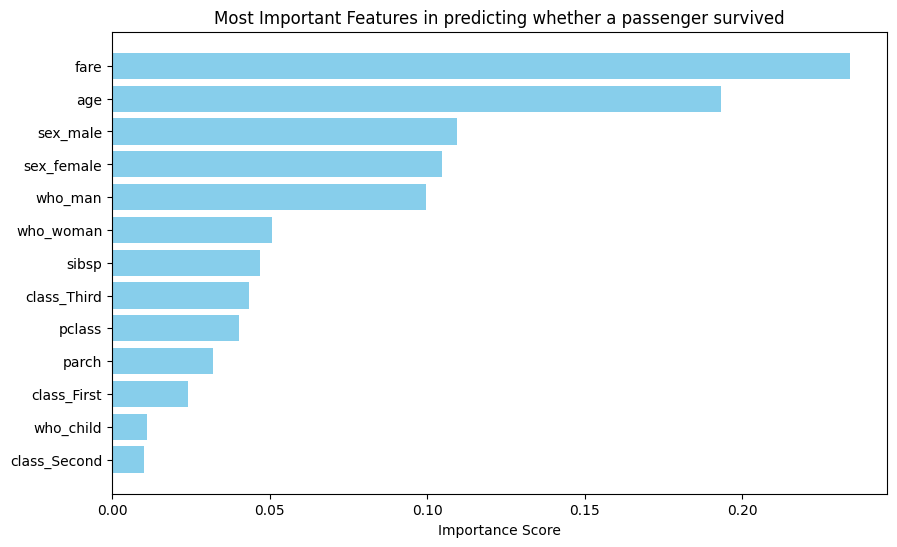

In [20]:
#display in bar plot
importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis() 
plt.title('Most Important Features in predicting whether a passenger survived')
plt.xlabel('Importance Score')
plt.show()

In [21]:
# Logistic Regression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

lr_param_grid = {
    'classifier__solver': ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced']
}

lr_model = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=2
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=No

In [22]:
#Logistic Regression classification report, best parameters, test accuracy, and ROC-AUC score
print("Logistic Regression")
print(classification_report(y_test, lr_pred))
print("Best Parameters:", lr_model.best_params_)
print(f"Test Accuracy: {accuracy_score(y_test, lr_pred):.2%}")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}")

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179

Best Parameters: {'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Test Accuracy: 82.68%
ROC-AUC: 0.8725


In [24]:
#Extract the logistic regression feature coefficients and plot their magnitude in a bar chart
coefficients = lr_model.best_estimator_.named_steps['classifier'].coef_[0]

# Combine numerical and categorical feature names
numerical_feature_names = numerical_features
categorical_feature_names = (lr_model.best_estimator_.named_steps['preprocessor']
                                     .named_transformers_['cat']
                                     .named_steps['onehot']
                                     .get_feature_names_out(categorical_features)
                            )
feature_names = numerical_feature_names + list(categorical_feature_names)

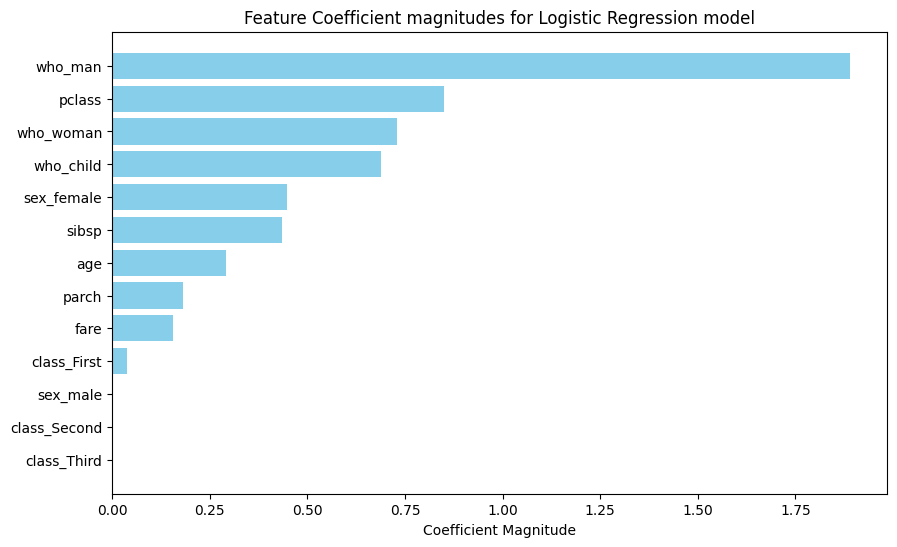

In [26]:
#Plot the feature coefficient magnitudes in a bar chart
# Create a DataFrame for the coefficients
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False, key=abs)  # Sort by absolute values

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Coefficient'].abs(), color='skyblue')
plt.gca().invert_yaxis()
plt.title('Feature Coefficient magnitudes for Logistic Regression model')
plt.xlabel('Coefficient Magnitude')
plt.show()


In [27]:
# Train a Support Vector Machine (SVM) model

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True, random_state=42))
])

# Define the parameter grid
svm_param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

# Create GridSearchCV
svm_model = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=2
)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END classifier__C=0.1, classifier__gamma=scale, classifier__kernel=linear; total time=   0.1s
[CV] END classifier__C=0.1, classifier__gamma=scale, classifier__kernel=linear; total time=   0.1s
[CV] END classifier__C=0.1, classifier__gamma=scale, classifier__kernel=linear; total time=   0.1s
[CV] END classifier__C=0.1, classifier__gamma=scale, classifier__kernel=linear; total time=   0.1s
[CV] END classifier__C=0.1, classifier__gamma=scale, classifier__kernel=linear; total time=   0.1s
[CV] END classifier__C=0.1, classifier__gamma=scale, classifier__kernel=rbf; total time=   0.1s
[CV] END classifier__C=0.1, classifier__gamma=scale, classifier__kernel=rbf; total time=   0.1s
[CV] END classifier__C=0.1, classifier__gamma=scale, classifier__kernel=rbf; total time=   0.1s
[CV] END classifier__C=0.1, classifier__gamma=scale, classifier__kernel=rbf; total time=   0.1s
[CV] END classifier__C=0.1, classifier__gamma=scale, classif

In [28]:
# Support Vector Machine classification report, best parameters, test accuracy, and ROC-AUC score for the SVM model
print("Support Vector Machine")
print(classification_report(y_test, svm_pred))
print("Best Parameters:", svm_model.best_params_)
print(f"Test Accuracy: {accuracy_score(y_test, svm_pred):.2%}")
print(f"ROC-AUC: {roc_auc_score(y_test, svm_prob):.4f}")

Support Vector Machine
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179

Best Parameters: {'classifier__C': 1, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Test Accuracy: 82.68%
ROC-AUC: 0.8408


In [ ]:
#SVM bar plot of feature importances is not straightforward because SVM does not provide feature importances directly. However, for linear kernels, you can use the coefficients as a proxy for feature importance. For non-linear kernels, you might consider using permutation importance or SHAP values.

In [29]:
# Train a K-Nearest Neighbours (KNN) model

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# Define the parameter grid
knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

# Create GridSearchCV
knn_model = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=2
)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
knn_pred = knn_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END classifier__metric=euclidean, classifier__n_neighbors=3, classifier__weights=uniform; total time=   0.0s
[CV] END classifier__metric=euclidean, classifier__n_neighbors=3, classifier__weights=uniform; total time=   0.0s
[CV] END classifier__metric=euclidean, classifier__n_neighbors=3, classifier__weights=uniform; total time=   0.0s
[CV] END classifier__metric=euclidean, classifier__n_neighbors=3, classifier__weights=uniform; total time=   0.0s
[CV] END classifier__metric=euclidean, classifier__n_neighbors=3, classifier__weights=uniform; total time=   0.0s
[CV] END classifier__metric=euclidean, classifier__n_neighbors=3, classifier__weights=distance; total time=   0.0s
[CV] END classifier__metric=euclidean, classifier__n_neighbors=3, classifier__weights=distance; total time=   0.0s
[CV] END classifier__metric=euclidean, classifier__n_neighbors=3, classifier__weights=distance; total time=   0.0s
[CV] END classifier__me

In [30]:
# K-Nearest Neighbours classification report, best parameters, and test accuracy for the KNN model
print("K-Nearest Neighbours")
print(classification_report(y_test, knn_pred))
print("Best Parameters:", knn_model.best_params_)
print(f"Test Accuracy: {accuracy_score(y_test, knn_pred):.2%}")
print(f"ROC-AUC: {roc_auc_score(y_test, knn_prob):.4f}")

K-Nearest Neighbours
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179

Best Parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}
Test Accuracy: 81.56%
ROC-AUC: 0.8360


In [ ]:
#KNN bar plot of feature importances is not straightforward because KNN does not provide feature importances directly. However, you might consider using permutation importance or SHAP values to assess feature importance for KNN models.

In [32]:
# Train a Gradient Boosting model

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Define the parameter grid
gb_param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [2, 3, 5]
}

# Create GridSearchCV
gb_model = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=2
)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]


Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=100; total time=   0.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=100; total time=   0.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=100; total time=   0.2s
[CV] END classifier__le

In [33]:

# Gradient Boosting classification report, best parameters, test accuracy, and ROC-AUC score for the Gradient Boosting model
print("Gradient Boosting")
print(classification_report(y_test, gb_pred))
print("Best Parameters:", gb_model.best_params_)
print(f"Test Accuracy: {accuracy_score(y_test, gb_pred):.2%}")
print(f"ROC-AUC: {roc_auc_score(y_test, gb_prob):.4f}")

Gradient Boosting
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       110
           1       0.76      0.65      0.70        69

    accuracy                           0.79       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179

Best Parameters: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 2, 'classifier__n_estimators': 100}
Test Accuracy: 78.77%
ROC-AUC: 0.8217


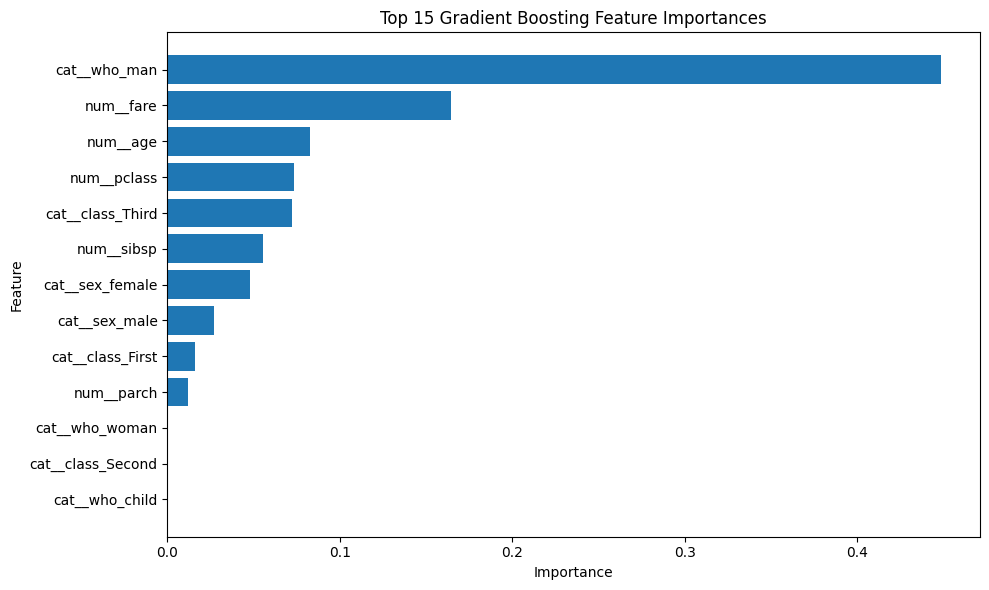

In [35]:
#Gradient Boosting bar plot of feature importances

# Get the best Gradient Boosting pipeline
gb_best = gb_model.best_estimator_

# Get the transformed feature names
feature_names = gb_best['preprocessor'].get_feature_names_out()

# Get feature importance values
gb_importances = gb_best['classifier'].feature_importances_

# Create a DataFrame
gb_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_importances
})

# Sort by importance
gb_feature_importance = gb_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    gb_feature_importance['Feature'].head(15),
    gb_feature_importance['Importance'].head(15)
)

plt.gca().invert_yaxis()

plt.title('Top 15 Gradient Boosting Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [36]:
# XGBoost

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [2, 3, 5],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0]
}

xgb_model = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=2
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]


Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=50, classifier__subsample=0.8; total time=   0.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=50, classifier__subsample=0.8; total time=   0.1s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=50, classifier__subsample=0.8; total time=   0.1s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=50, classifier__subsample=0.8; total time=   0.1s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=50, classifier__subsample=0.8; total time=   0.1s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=50, classifier__subsample=1.0; total time=   0.1s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=2, classifier__n_estimators=5

In [37]:
#XGBoost classification report, best parameters, test accuracy, and ROC-AUC score for the XGBoost model
print("XGBoost")
print(classification_report(y_test, xgb_pred))
print("Best Parameters:", xgb_model.best_params_)
print(f"Test Accuracy: {accuracy_score(y_test, xgb_pred):.2%}")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}")

XGBoost
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.68      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179

Best Parameters: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 2, 'classifier__n_estimators': 150, 'classifier__subsample': 1.0}
Test Accuracy: 79.89%
ROC-AUC: 0.8277


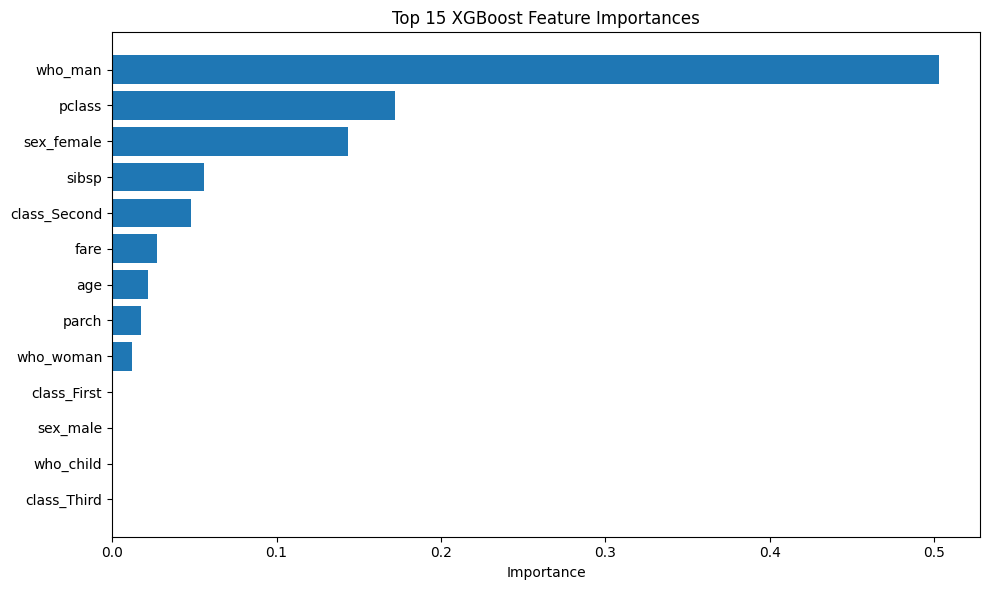

In [38]:
# XGBoost Feature Importance

xgb_best = xgb_model.best_estimator_

feature_names = (
    numerical_features +
    list(
        xgb_best['preprocessor']
        .named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(categorical_features)
    )
)

xgb_importances = xgb_best['classifier'].feature_importances_

xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importances
}).sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    xgb_importance_df['Feature'].head(15),
    xgb_importance_df['Importance'].head(15)
)

plt.gca().invert_yaxis()

plt.title('Top 15 XGBoost Feature Importances')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

In [39]:
# ==============================
# Model Comparison
# ==============================

models = {
    'Random Forest': (rf_pred, rf_prob),
    'Logistic Regression': (lr_pred, lr_prob),
    'Support Vector Machine': (svm_pred, svm_prob),
    'K-Nearest Neighbours': (knn_pred, knn_prob),
    'Gradient Boosting': (gb_pred, gb_prob),
    'XGBoost': (xgb_pred, xgb_prob)
}

results = []

for model_name, (predictions, probabilities) in models.items():

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1 Score': f1_score(y_test, predictions),
        'ROC-AUC': roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.826816,0.806452,0.724638,0.763359,0.872464
1,Random Forest,0.810056,0.769231,0.724638,0.746269,0.841041
2,Support Vector Machine,0.826816,0.796875,0.739130,0.766917,0.840843
3,K-Nearest Neighbours,0.815642,0.764706,0.753623,0.759124,0.836034
4,XGBoost,0.798883,0.770492,0.681159,0.723077,0.827734
5,Gradient Boosting,0.787709,0.762712,0.652174,0.703125,0.821739


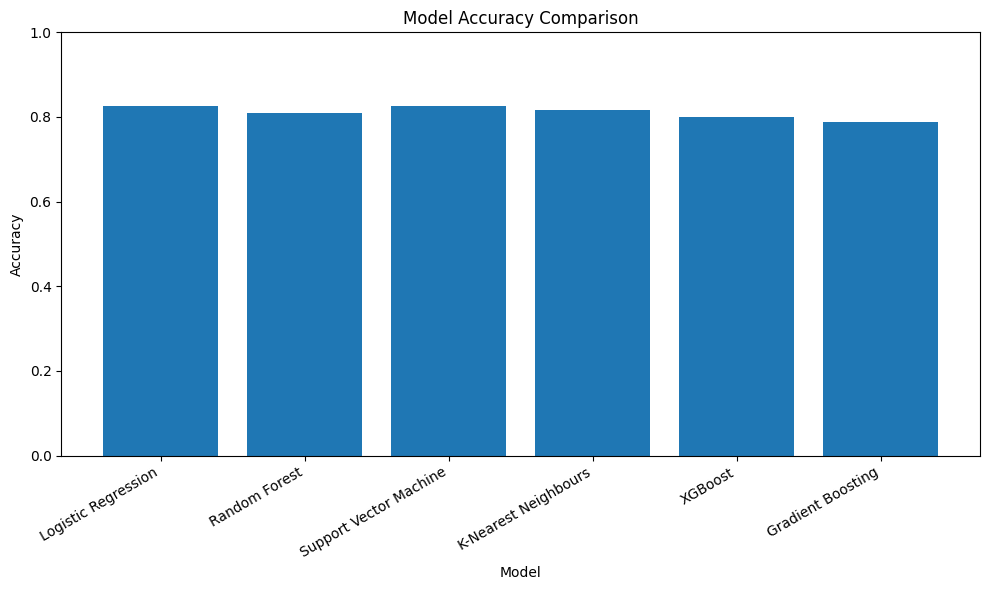

In [40]:
# Plot model accuracy comparison

plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Model'],
    results_df['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

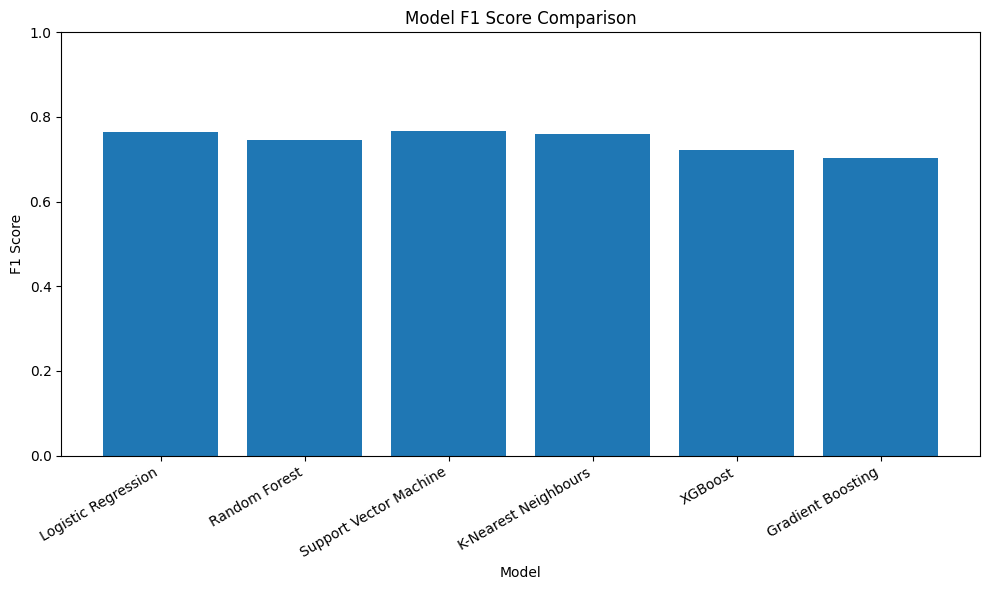

In [41]:
# F1 Score Comparison

plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Model'],
    results_df['F1 Score']
)

plt.title('Model F1 Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1 Score')

plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

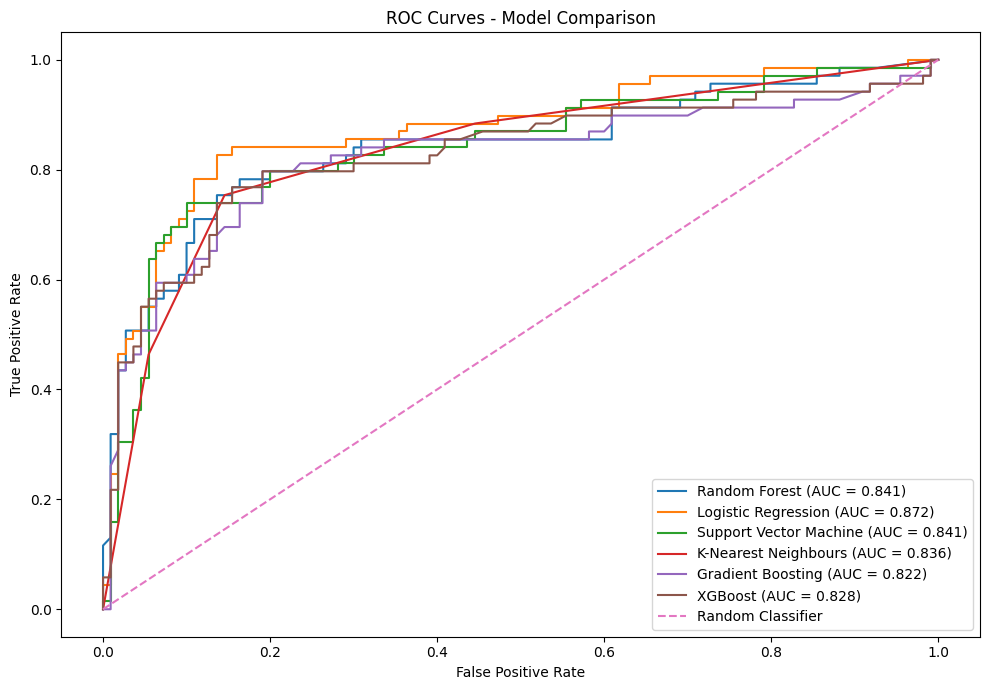

In [42]:
# ROC Curves

plt.figure(figsize=(10, 7))

for model_name, (predictions, probabilities) in models.items():

    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_score = roc_auc_score(y_test, probabilities)

    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC = {auc_score:.3f})'
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title('ROC Curves - Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

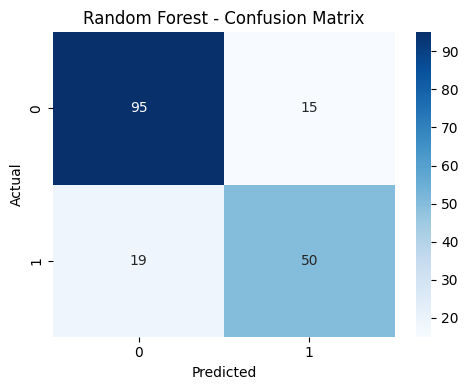

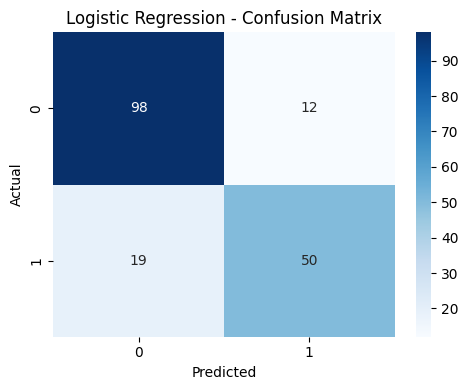

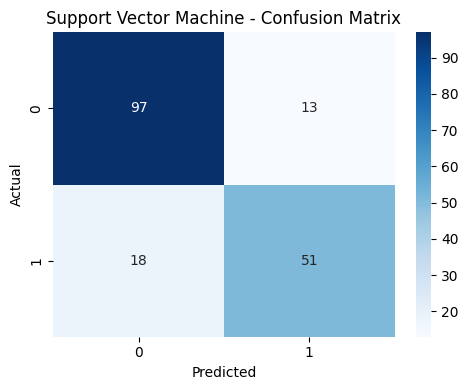

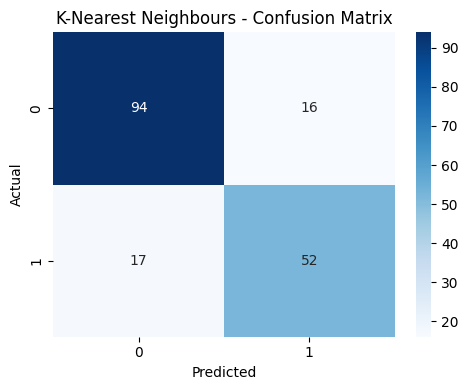

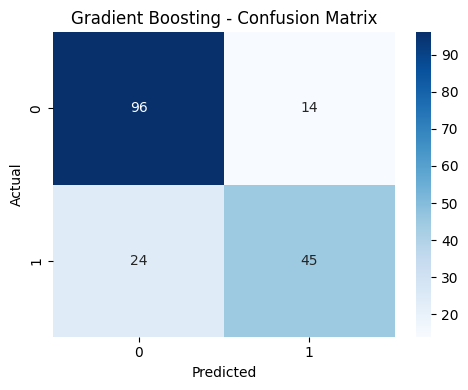

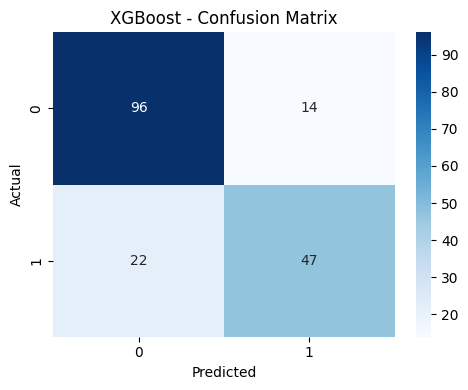

In [43]:
# Confusion Matrices

for model_name, (predictions, probabilities) in models.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()

In [44]:
# Cross-Validation Comparison

cv_results = []

grid_models = {
    'Random Forest': rf_model,
    'Logistic Regression': lr_model,
    'Support Vector Machine': svm_model,
    'K-Nearest Neighbours': knn_model,
    'Gradient Boosting': gb_model,
    'XGBoost': xgb_model
}

for model_name, grid_model in grid_models.items():

    best_index = grid_model.best_index_

    mean_cv_score = grid_model.cv_results_[
        'mean_test_score'
    ][best_index]

    std_cv_score = grid_model.cv_results_[
        'std_test_score'
    ][best_index]

    cv_results.append({
        'Model': model_name,
        'Mean CV Accuracy': mean_cv_score,
        'CV Std': std_cv_score
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by='Mean CV Accuracy',
    ascending=False
)

cv_results_df

,Model,Mean CV Accuracy,CV Std
0,Random Forest,0.839870,0.019233
5,XGBoost,0.835763,0.037478
4,Gradient Boosting,0.832788,0.024158
2,Support Vector Machine,0.824525,0.026412
3,K-Nearest Neighbours,0.821629,0.023741
1,Logistic Regression,0.820270,0.033496
